In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection    import train_test_split, cross_val_score
from sklearn.linear_model       import LinearRegression
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.metrics            import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection         import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'

os.makedirs('images', exist_ok=True)
os.makedirs('data',   exist_ok=True)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
df = pd.read_csv('data/housing.csv')

print("Dataset Loaded")
print(f"Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns   : {df.columns.tolist()}")
print(f"\nFirst 5 Rows:")
df.head()

Dataset Loaded
Shape     : 20,640 rows × 10 columns
Columns   : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

First 5 Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
print("=" * 55)
print("     DATASET INFO")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("     OCEAN PROXIMITY CATEGORIES")
print("=" * 55)
print(df['ocean_proximity'].value_counts())

     DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

     OCEAN PROXIMITY CATEGORIES
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [6]:
print("=" * 55)
print("     DESCRIPTIVE STATISTICS")
print("=" * 55)
print(df.describe().round(2))

print("\n" + "=" * 55)
print("     KEY METRICS")
print("=" * 55)
print(f"  Total Records           : {len(df):,}")
print(f"  Missing Values          : {df.isnull().sum().sum()}")
print(f"  Missing in total_bedrooms: {df['total_bedrooms'].isnull().sum()}")
print(f"  Avg Median House Value  : ${df['median_house_value'].mean():,.0f}")
print(f"  Max Median House Value  : ${df['median_house_value'].max():,.0f}")
print(f"  Min Median House Value  : ${df['median_house_value'].min():,.0f}")
print(f"  Avg Median Income       : {df['median_income'].mean():.2f}")
print(f"  Ocean Proximity Cats    : {df['ocean_proximity'].nunique()}")

     DESCRIPTIVE STATISTICS
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
count   20640.00  20640.00            20640.00     20640.00        20433.00   
mean     -119.57     35.63               28.64      2635.76          537.87   
std         2.00      2.14               12.59      2181.62          421.39   
min      -124.35     32.54                1.00         2.00            1.00   
25%      -121.80     33.93               18.00      1447.75          296.00   
50%      -118.49     34.26               29.00      2127.00          435.00   
75%      -118.01     37.71               37.00      3148.00          647.00   
max      -114.31     41.95               52.00     39320.00         6445.00   

       population  households  median_income  median_house_value  
count    20640.00    20640.00       20640.00            20640.00  
mean      1425.48      499.54           3.87           206855.82  
std       1132.46      382.33           1.90           1153

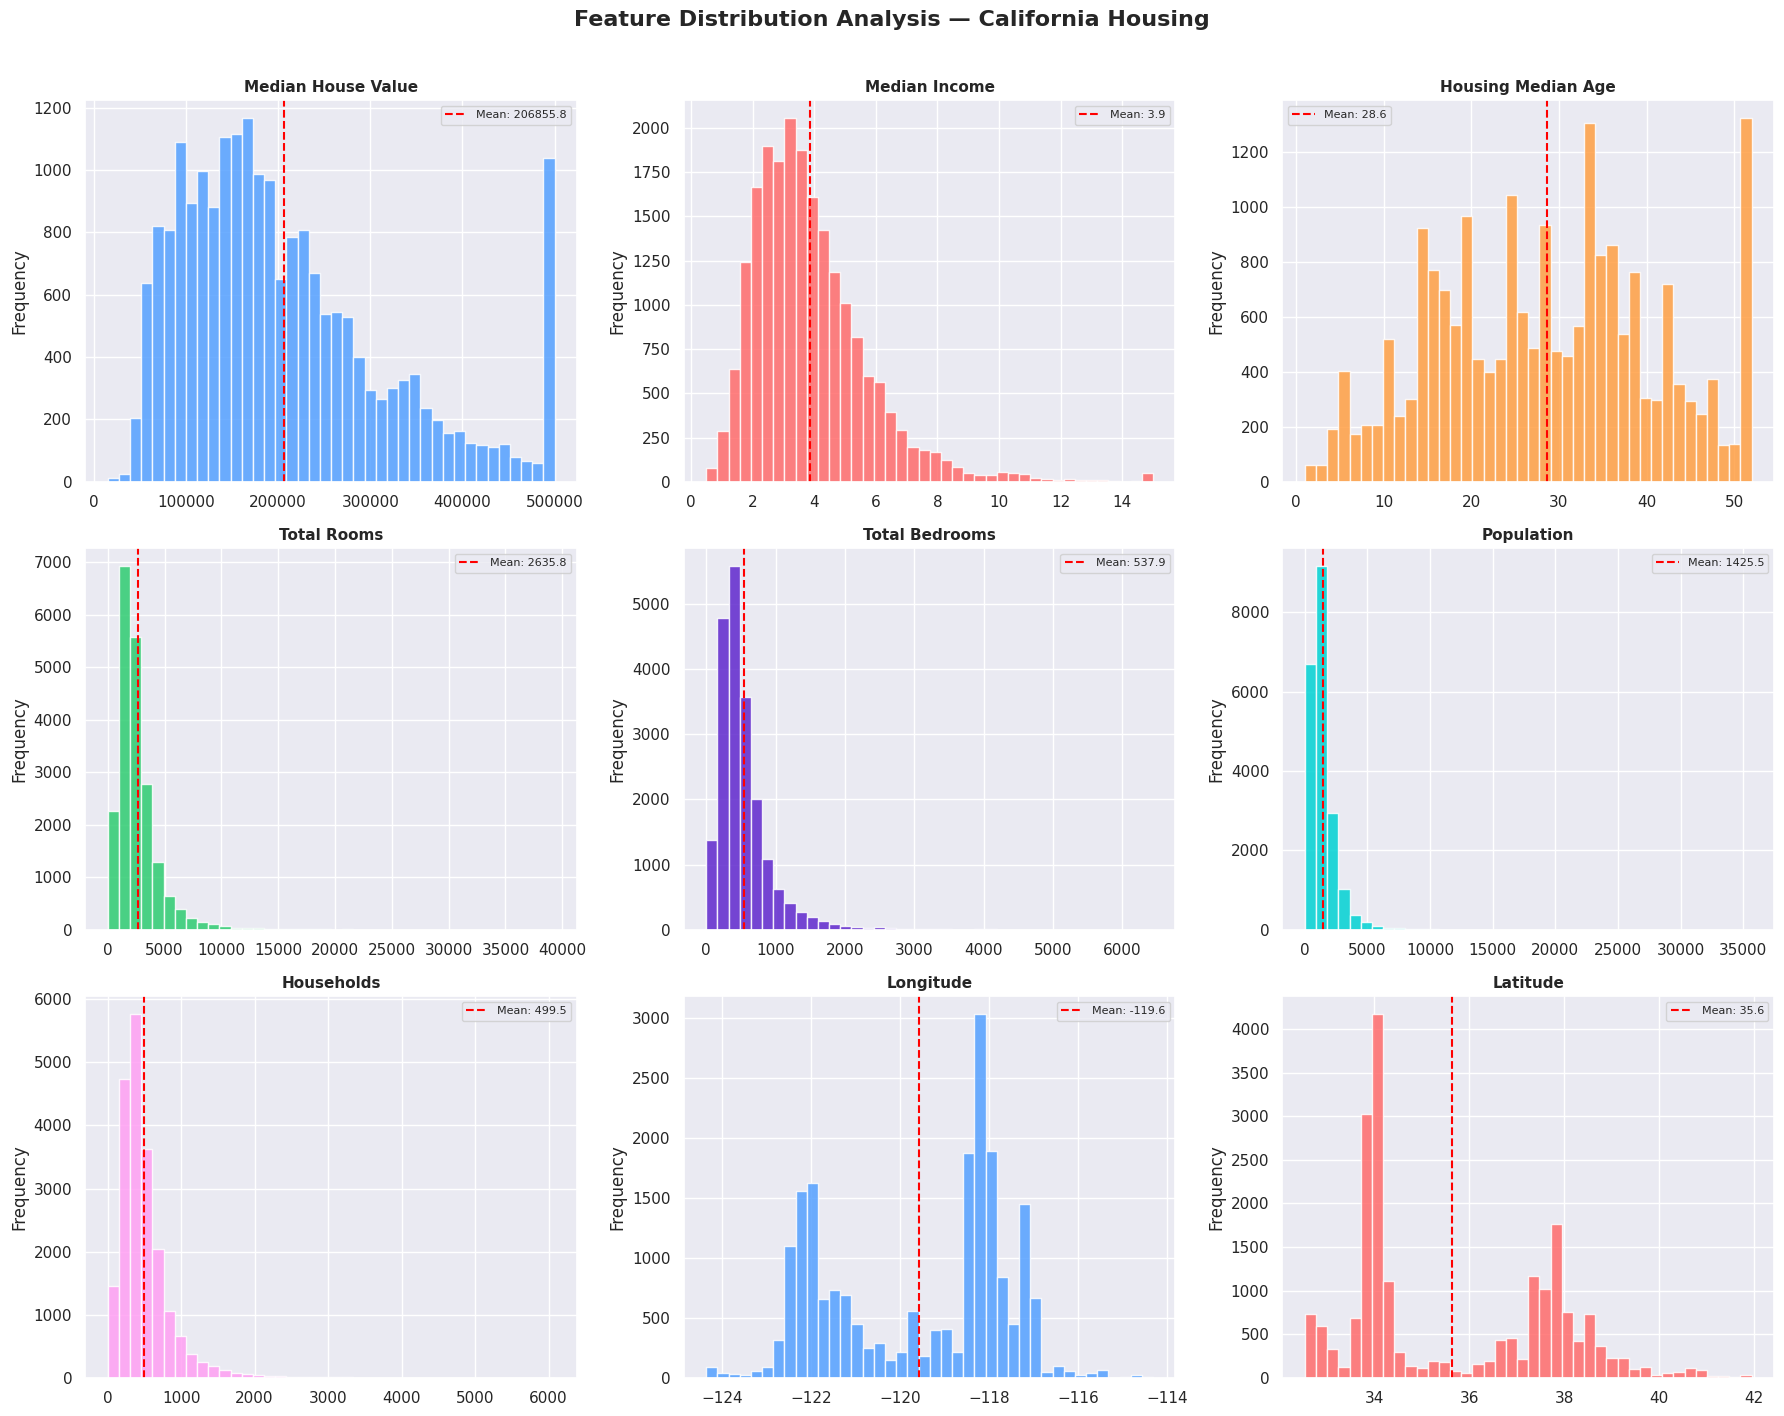

In [7]:
num_cols = ['median_house_value', 'median_income',
            'housing_median_age', 'total_rooms',
            'total_bedrooms', 'population',
            'households', 'longitude', 'latitude']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

colors = ['#54A0FF','#FF6B6B','#FF9F43','#2ecc71',
          '#5F27CD','#00D2D3','#FF9FF3','#54A0FF','#FF6B6B']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40,
                 color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red',
                    linestyle='--', linewidth=1.5,
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(col.replace('_', ' ').title(),
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distribution Analysis — California Housing',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

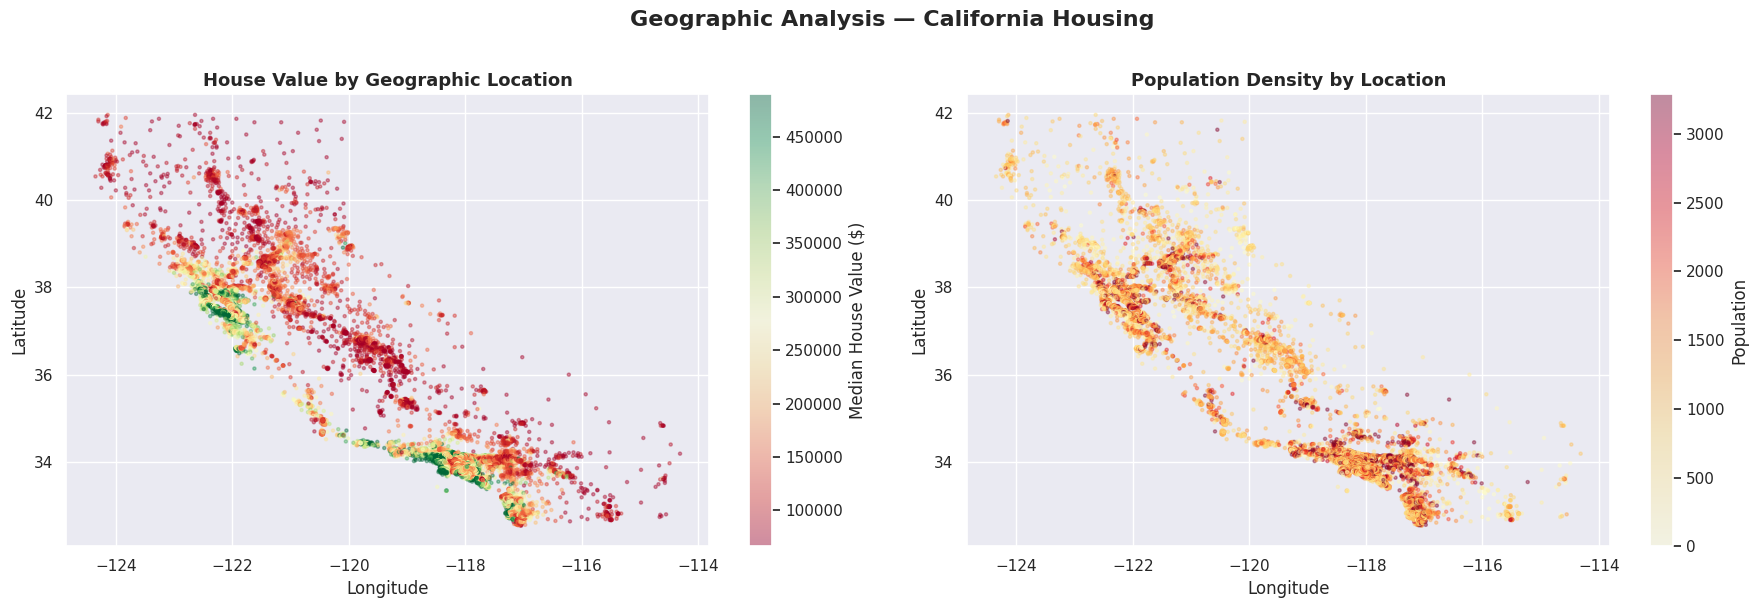

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# House value geographic scatter
scatter1 = axes[0].scatter(
    df['longitude'], df['latitude'],
    c=df['median_house_value'],
    cmap='RdYlGn', alpha=0.4, s=5,
    vmin=df['median_house_value'].quantile(0.05),
    vmax=df['median_house_value'].quantile(0.95)
)
plt.colorbar(scatter1, ax=axes[0], label='Median House Value ($)')
axes[0].set_title('House Value by Geographic Location',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Population geographic scatter
scatter2 = axes[1].scatter(
    df['longitude'], df['latitude'],
    c=df['population'],
    cmap='YlOrRd', alpha=0.4, s=5,
    vmin=0,
    vmax=df['population'].quantile(0.95)
)
plt.colorbar(scatter2, ax=axes[1], label='Population')
axes[1].set_title('Population Density by Location',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Geographic Analysis — California Housing',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

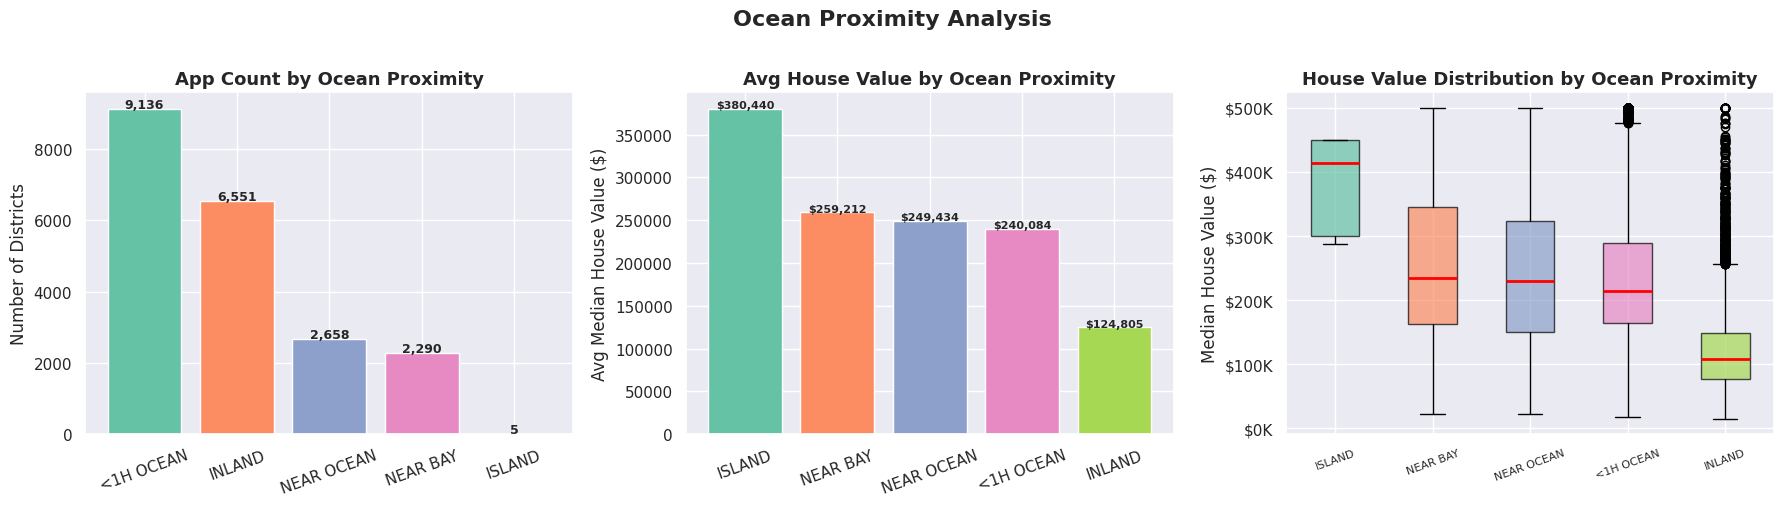

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_op = sns.color_palette('Set2', 5)

# Count
op_counts = df['ocean_proximity'].value_counts()
bars = axes[0].bar(op_counts.index, op_counts.values,
                   color=colors_op, edgecolor='white')
axes[0].set_title('App Count by Ocean Proximity',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Districts')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontsize=9, fontweight='bold')

# Avg house value by ocean proximity
op_value = df.groupby('ocean_proximity')['median_house_value']\
             .mean().sort_values(ascending=False)
bars2 = axes[1].bar(op_value.index, op_value.values,
                    color=colors_op, edgecolor='white')
axes[1].set_title('Avg House Value by Ocean Proximity',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Median House Value ($)')
axes[1].tick_params(axis='x', rotation=20)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1000,
                 f'${bar.get_height():,.0f}',
                 ha='center', fontsize=8, fontweight='bold')

# Boxplot
bp_data = [df[df['ocean_proximity']==cat]['median_house_value'].dropna()
           for cat in op_value.index]
bp = axes[2].boxplot(bp_data, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], colors_op):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_xticklabels(op_value.index, rotation=20, fontsize=8)
axes[2].set_title('House Value Distribution by Ocean Proximity',
                   fontsize=13, fontweight='bold')
axes[2].set_ylabel('Median House Value ($)')
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Ocean Proximity Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/ocean_proximity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

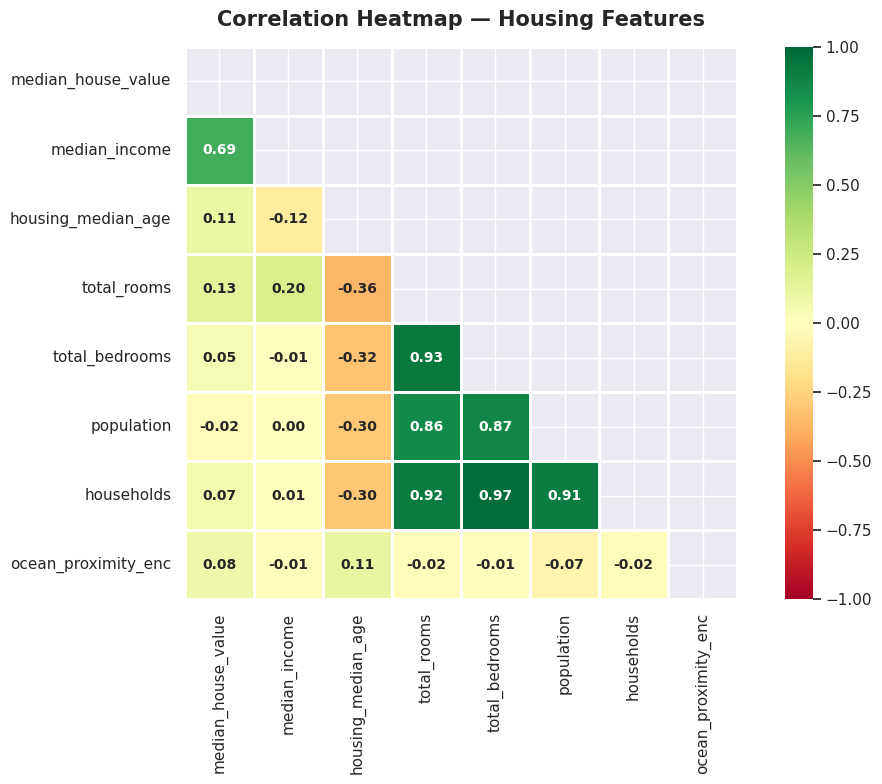

In [10]:
# Encode ocean_proximity for correlation
df_encoded = df.copy()
le = LabelEncoder()
df_encoded['ocean_proximity_enc'] = le.fit_transform(df_encoded['ocean_proximity'])
df_encoded['total_bedrooms'].fillna(df_encoded['total_bedrooms'].median(), inplace=True)

corr_cols = ['median_house_value', 'median_income',
             'housing_median_age', 'total_rooms',
             'total_bedrooms', 'population',
             'households', 'ocean_proximity_enc']
corr = df_encoded[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.8, square=True, mask=mask,
            annot_kws={'size': 10, 'weight': 'bold'},
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Housing Features',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

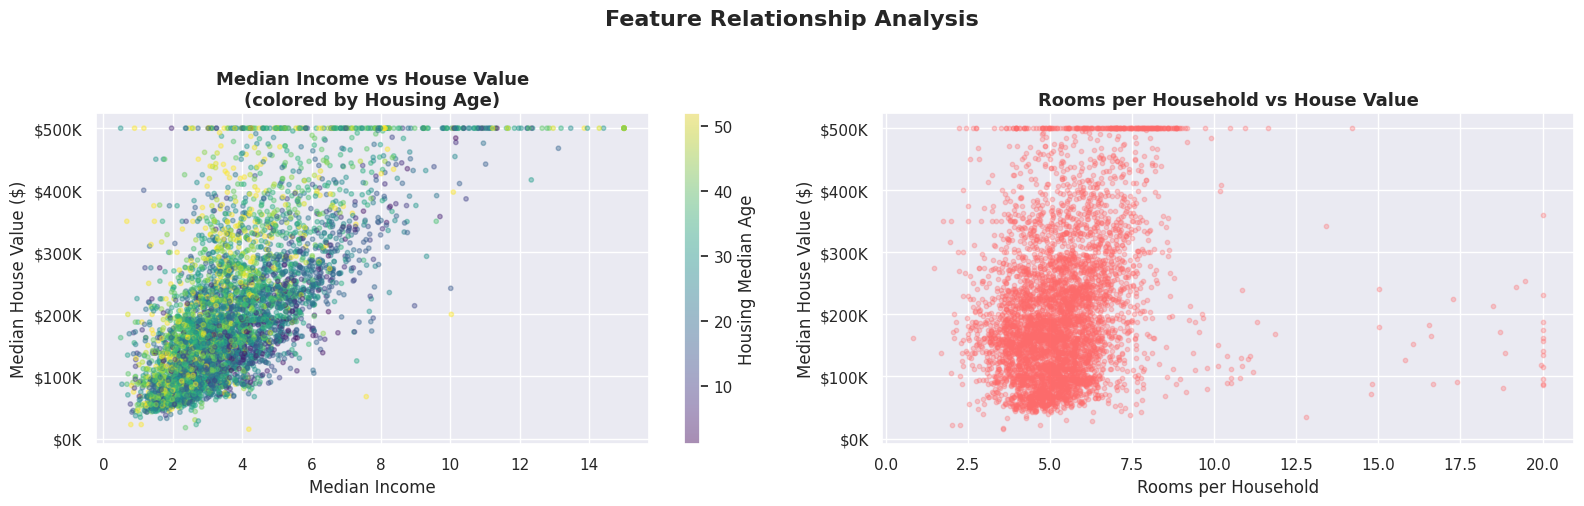

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter — income vs house value
sample = df.sample(min(5000, len(df)), random_state=42)
scatter = axes[0].scatter(
    sample['median_income'],
    sample['median_house_value'],
    c=sample['housing_median_age'],
    cmap='viridis', alpha=0.4, s=10
)
plt.colorbar(scatter, ax=axes[0], label='Housing Median Age')
axes[0].set_title('Median Income vs House Value\n(colored by Housing Age)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Median House Value ($)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Rooms per household vs house value
df_encoded['rooms_per_household'] = (
    df_encoded['total_rooms'] / df_encoded['households'])
sample2 = df_encoded.sample(min(5000, len(df_encoded)), random_state=42)
axes[1].scatter(
    sample2['rooms_per_household'].clip(0, 20),
    sample2['median_house_value'],
    alpha=0.3, color='#FF6B6B', s=10)
axes[1].set_title('Rooms per Household vs House Value',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rooms per Household')
axes[1].set_ylabel('Median House Value ($)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Feature Relationship Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print("=" * 55)
print("     DATA PREPROCESSING & FEATURE ENGINEERING")
print("=" * 55)

df_model = df.copy()

# Fill missing total_bedrooms with median
df_model['total_bedrooms'].fillna(df_model['total_bedrooms'].median(),
                                   inplace=True)
print(f"Missing total_bedrooms filled: {df['total_bedrooms'].isnull().sum()} → 0")

# Feature Engineering — derived features
df_model['rooms_per_household']    = df_model['total_rooms']    / df_model['households']
df_model['bedrooms_per_room']      = df_model['total_bedrooms'] / df_model['total_rooms']
df_model['population_per_household']= df_model['population']   / df_model['households']

print("\nNew Features Created:")
print("  rooms_per_household     = total_rooms / households")
print("  bedrooms_per_room       = total_bedrooms / total_rooms")
print("  population_per_household= population / households")

# One-Hot Encode ocean_proximity
df_model = pd.get_dummies(df_model, columns=['ocean_proximity'], drop_first=True)
print(f"\nAfter encoding, shape : {df_model.shape}")

# Features and target
drop_cols = ['median_house_value', 'longitude', 'latitude']
X = df_model.drop(columns=drop_cols)
y = df_model['median_house_value']

print(f"Features (X) shape    : {X.shape}")
print(f"Target   (y) shape    : {y.shape}")
print(f"\nFeatures used:")
for col in X.columns:
    print(f"  — {col}")

     DATA PREPROCESSING & FEATURE ENGINEERING
Missing total_bedrooms filled: 207 → 0

New Features Created:
  rooms_per_household     = total_rooms / households
  bedrooms_per_room       = total_bedrooms / total_rooms
  population_per_household= population / households

After encoding, shape : (20640, 16)
Features (X) shape    : (20640, 13)
Target   (y) shape    : (20640,)

Features used:
  — housing_median_age
  — total_rooms
  — total_bedrooms
  — population
  — households
  — median_income
  — rooms_per_household
  — bedrooms_per_room
  — population_per_household
  — ocean_proximity_INLAND
  — ocean_proximity_ISLAND
  — ocean_proximity_NEAR BAY
  — ocean_proximity_NEAR OCEAN


In [13]:
print("=" * 55)
print("     TRAIN TEST SPLIT & FEATURE SCALING")
print("=" * 55)

# Train-test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training Set   : {X_train.shape[0]:,} samples")
print(f"Test Set       : {X_test.shape[0]:,} samples")
print(f"Split Ratio    : 80% Train / 20% Test")

# Feature Scaling
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nStandardScaler applied")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled  shape : {X_test_scaled.shape}")
print("\nData Ready for Model Training")

     TRAIN TEST SPLIT & FEATURE SCALING
Training Set   : 16,512 samples
Test Set       : 4,128 samples
Split Ratio    : 80% Train / 20% Test

StandardScaler applied
X_train_scaled shape : (16512, 13)
X_test_scaled  shape : (4128, 13)

Data Ready for Model Training


In [14]:
print("=" * 55)
print("     LINEAR REGRESSION MODEL TRAINING")
print("=" * 55)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model Trained Successfully")
print(f"\nIntercept  : {model.intercept_:,.2f}")
print(f"\nCoefficients:")
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

     LINEAR REGRESSION MODEL TRAINING
Model Trained Successfully

Intercept  : 207,194.69

Coefficients:
                   Feature   Coefficient
             median_income  81804.443802
                households  46269.173229
         bedrooms_per_room  16637.199719
        housing_median_age  15475.856577
       rooms_per_household   5411.509529
               total_rooms   4237.675927
ocean_proximity_NEAR OCEAN   4152.454293
    ocean_proximity_ISLAND   2378.125468
  ocean_proximity_NEAR BAY   1199.936097
  population_per_household    517.034907
            total_bedrooms    190.006118
    ocean_proximity_INLAND -29907.032747
                population -45085.271187


In [15]:
print("=" * 55)
print("     MODEL EVALUATION")
print("=" * 55)

# Predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

# Metrics — Train
train_r2   = r2_score(y_train, y_pred_train)
train_mse  = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_mae  = mean_absolute_error(y_train, y_pred_train)

# Metrics — Test
test_r2    = r2_score(y_test, y_pred_test)
test_mse   = mean_squared_error(y_test, y_pred_test)
test_rmse  = np.sqrt(test_mse)
test_mae   = mean_absolute_error(y_test, y_pred_test)

# Cross Validation
cv_scores  = cross_val_score(model, X_train_scaled, y_train,
                              cv=5, scoring='r2')

print(f"\n  {'Metric':<25} {'Train':>12} {'Test':>12}")
print(f"  {'-'*50}")
print(f"  {'R² Score':<25} {train_r2:>12.4f} {test_r2:>12.4f}")
print(f"  {'MSE':<25} {train_mse:>12,.0f} {test_mse:>12,.0f}")
print(f"  {'RMSE':<25} ${train_rmse:>11,.0f} ${test_rmse:>11,.0f}")
print(f"  {'MAE':<25} ${train_mae:>11,.0f} ${test_mae:>11,.0f}")
print(f"\n  Cross-Validation R² (5-fold):")
print(f"  Scores : {[round(s,4) for s in cv_scores]}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std    : {cv_scores.std():.4f}")

     MODEL EVALUATION

  Metric                           Train         Test
  --------------------------------------------------
  R² Score                        0.6453       0.5878
  MSE                       4,741,672,973 5,402,094,982
  RMSE                      $     68,860 $     73,499
  MAE                       $     49,552 $     51,497

  Cross-Validation R² (5-fold):
  Scores : [np.float64(0.6508), np.float64(0.6424), np.float64(0.6543), np.float64(0.6436), np.float64(0.6231)]
  Mean   : 0.6428
  Std    : 0.0108


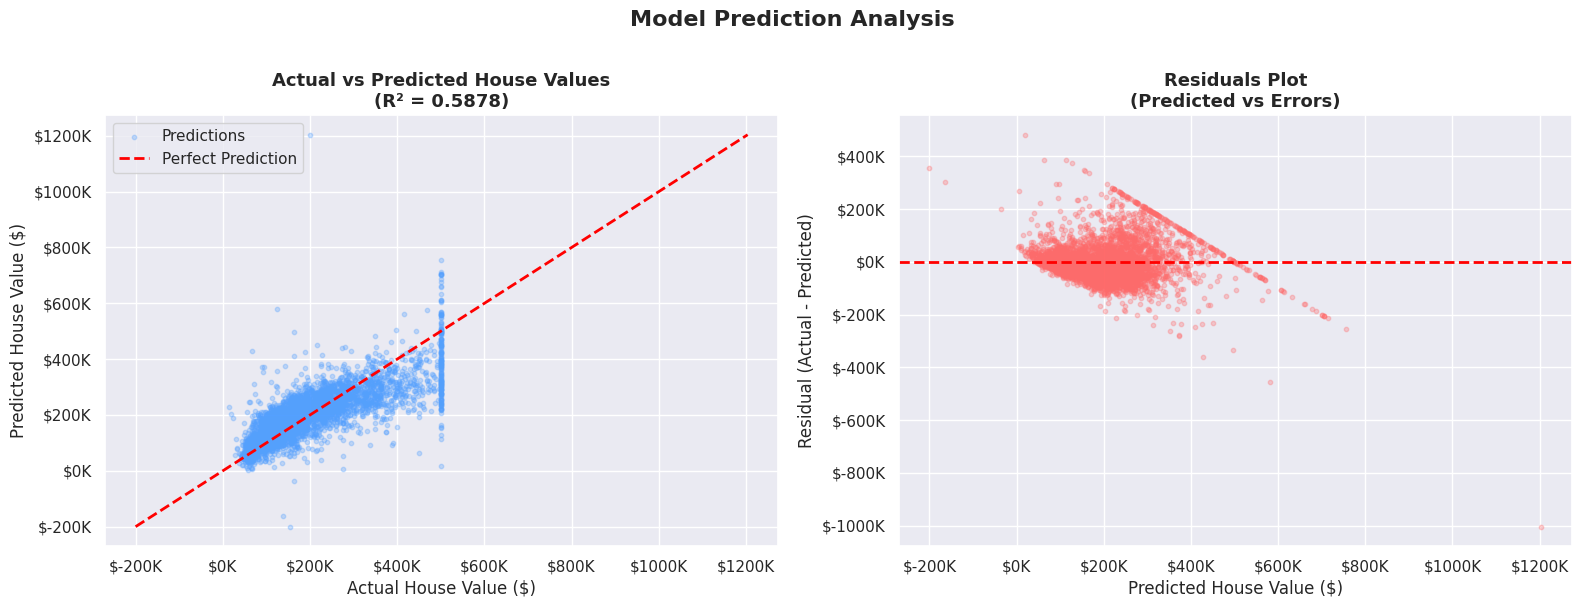

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred_test,
                alpha=0.3, color='#54A0FF', s=10, label='Predictions')
# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2, linestyle='--',
             label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted House Values\n(R² = {test_r2:.4f})',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual House Value ($)')
axes[0].set_ylabel('Predicted House Value ($)')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend()

# Residuals plot
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals,
                alpha=0.3, color='#FF6B6B', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Plot\n(Predicted vs Errors)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted House Value ($)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Model Prediction Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

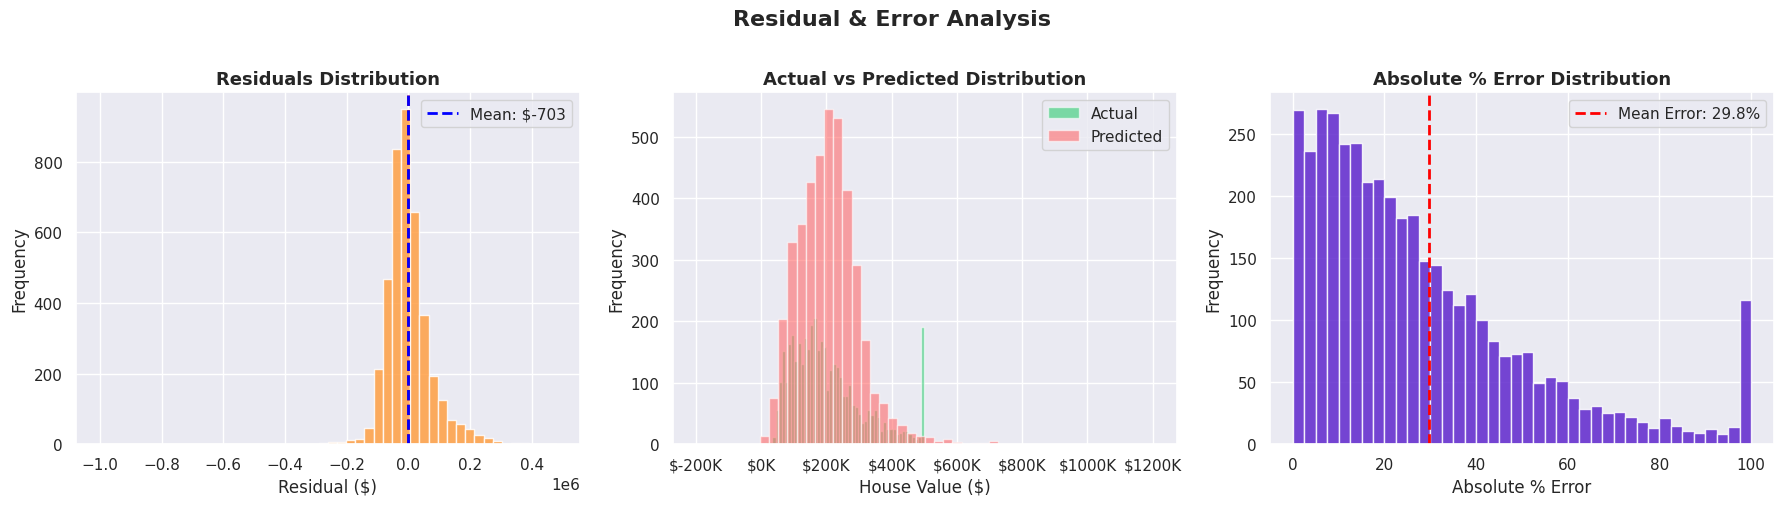

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual histogram
axes[0].hist(residuals, bins=50, color='#FF9F43',
             edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].axvline(residuals.mean(), color='blue', linestyle='--',
                linewidth=2, label=f'Mean: ${residuals.mean():,.0f}')
axes[0].set_title('Residuals Distribution',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Actual vs Predicted — density
axes[1].hist(y_test.values, bins=50, alpha=0.6,
             color='#2ecc71', edgecolor='white', label='Actual')
axes[1].hist(y_pred_test, bins=50, alpha=0.6,
             color='#FF6B6B', edgecolor='white', label='Predicted')
axes[1].set_title('Actual vs Predicted Distribution',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('House Value ($)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].legend()

# Error percentage distribution
pct_error = np.abs(residuals / y_test) * 100
axes[2].hist(pct_error.clip(0, 100), bins=40,
             color='#5F27CD', edgecolor='white', alpha=0.85)
axes[2].axvline(pct_error.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean Error: {pct_error.mean():.1f}%')
axes[2].set_title('Absolute % Error Distribution',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Absolute % Error')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Residual & Error Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

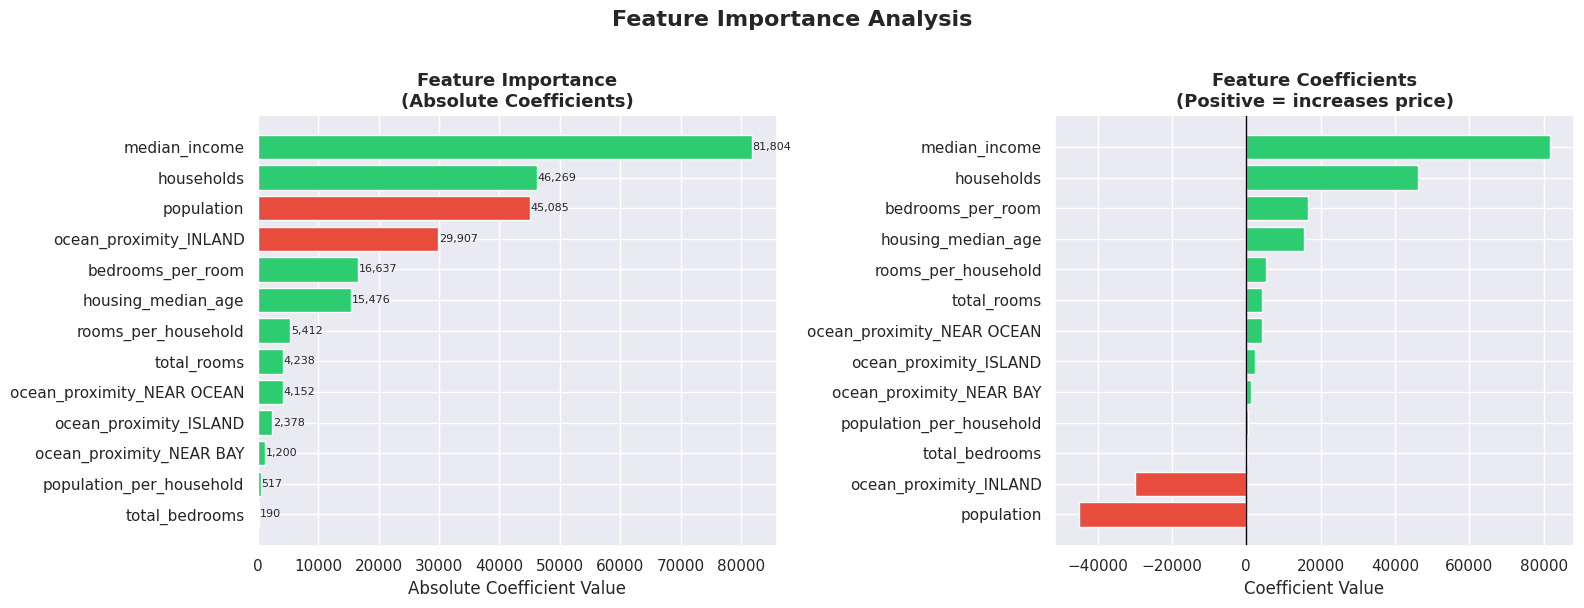

In [18]:
# Coefficient-based importance
coef_abs = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': np.abs(model.coef_)
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Abs coefficient bar
colors_fi = ['#2ecc71' if c > 0 else '#e74c3c'
             for c in model.coef_[
                 np.argsort(np.abs(model.coef_))[::-1]]]
bars = axes[0].barh(
    coef_abs['Feature'][::-1],
    coef_abs['Importance'][::-1],
    color=colors_fi[::-1],
    edgecolor='white'
)
axes[0].set_title('Feature Importance\n(Absolute Coefficients)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient Value')
for bar in bars:
    axes[0].text(bar.get_width() + 100,
                 bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():,.0f}',
                 va='center', fontsize=8)

# Signed coefficients
coef_signed = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=True)
colors_signed = ['#e74c3c' if v < 0 else '#2ecc71'
                 for v in coef_signed['Coefficient']]
axes[1].barh(coef_signed['Feature'],
             coef_signed['Coefficient'],
             color=colors_signed, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Feature Coefficients\n(Positive = increases price)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient Value')

plt.suptitle('Feature Importance Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

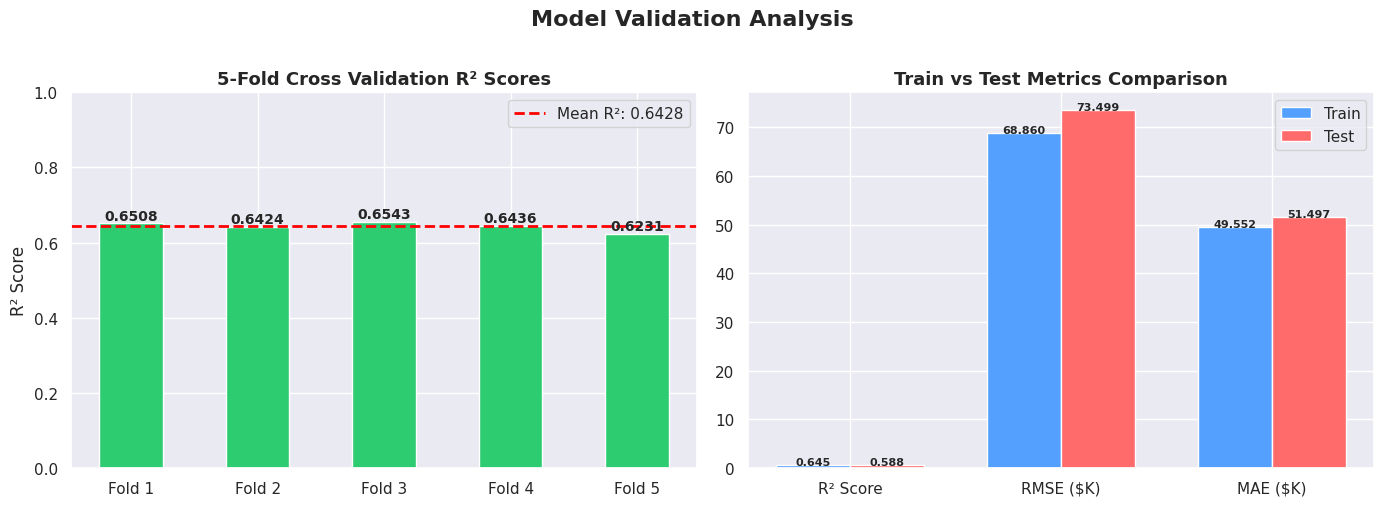

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV scores bar
fold_labels = [f'Fold {i+1}' for i in range(len(cv_scores))]
colors_cv   = ['#2ecc71' if s > 0.6 else '#FF9F43' for s in cv_scores]
bars = axes[0].bar(fold_labels, cv_scores,
                   color=colors_cv, edgecolor='white', width=0.5)
axes[0].axhline(cv_scores.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean R²: {cv_scores.mean():.4f}')
axes[0].set_title('5-Fold Cross Validation R² Scores',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
axes[0].legend()
for bar, score in zip(bars, cv_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{score:.4f}',
                 ha='center', fontsize=10, fontweight='bold')

# Train vs Test metrics comparison
metrics      = ['R² Score', 'RMSE ($K)', 'MAE ($K)']
train_vals   = [train_r2, train_rmse/1000, train_mae/1000]
test_vals    = [test_r2,  test_rmse/1000,  test_mae/1000]
x_pos        = np.arange(len(metrics))
width        = 0.35
axes[1].bar(x_pos - width/2, train_vals, width,
            label='Train', color='#54A0FF', edgecolor='white')
axes[1].bar(x_pos + width/2, test_vals,  width,
            label='Test',  color='#FF6B6B', edgecolor='white')
axes[1].set_title('Train vs Test Metrics Comparison',
                   fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(metrics)
axes[1].legend()
for i, (tv, tsv) in enumerate(zip(train_vals, test_vals)):
    axes[1].text(i - width/2, tv + 0.01,
                 f'{tv:.3f}', ha='center', fontsize=8, fontweight='bold')
    axes[1].text(i + width/2, tsv + 0.01,
                 f'{tsv:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Model Validation Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/model_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print("=" * 65)
print("     SAMPLE PREDICTIONS vs ACTUAL VALUES")
print("=" * 65)

sample_idx    = np.random.choice(len(y_test), 15, replace=False)
actual_sample = y_test.iloc[sample_idx].values
pred_sample   = y_pred_test[sample_idx]
errors        = actual_sample - pred_sample
pct_errors    = np.abs(errors / actual_sample) * 100

print(f"\n  {'#':<4} {'Actual':>12} {'Predicted':>12} "
      f"{'Error':>12} {'% Error':>10}")
print(f"  {'-'*55}")
for i in range(15):
    print(f"  {i+1:<4} ${actual_sample[i]:>10,.0f} "
          f"${pred_sample[i]:>10,.0f} "
          f"${errors[i]:>10,.0f} "
          f"{pct_errors[i]:>9.1f}%")

print(f"\n  Average % Error : {pct_errors.mean():.2f}%")
print(f"  Best Prediction : {pct_errors.min():.2f}% error")
print(f"  Worst Prediction: {pct_errors.max():.2f}% error")

     SAMPLE PREDICTIONS vs ACTUAL VALUES

  #          Actual    Predicted        Error    % Error
  -------------------------------------------------------
  1    $   241,300 $   291,723 $   -50,423      20.9%
  2    $   132,100 $   125,379 $     6,721       5.1%
  3    $   300,500 $   175,595 $   124,905      41.6%
  4    $   213,200 $   159,773 $    53,427      25.1%
  5    $   234,600 $   193,589 $    41,011      17.5%
  6    $    91,500 $   173,713 $   -82,213      89.9%
  7    $   170,900 $   213,792 $   -42,892      25.1%
  8    $   245,200 $   151,492 $    93,708      38.2%
  9    $   101,600 $   119,382 $   -17,782      17.5%
  10   $   230,900 $   234,301 $    -3,401       1.5%
  11   $   325,500 $   358,363 $   -32,863      10.1%
  12   $   173,800 $   174,603 $      -803       0.5%
  13   $   500,001 $   374,995 $   125,006      25.0%
  14   $   500,001 $   381,214 $   118,787      23.8%
  15   $   134,200 $   170,023 $   -35,823      26.7%

  Average % Error : 24.55%
  Bes

In [21]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║        KEY INSIGHTS — HOUSE PRICE PREDICTION                     ║
╠══════════════════════════════════════════════════════════════════╣
""")
print(f"  INSIGHT 1 — Model Performance")
print(f"  R² Score of {test_r2:.4f} — model explains "
      f"{test_r2*100:.1f}% of house price variance")
print(f"  → Solid baseline performance for linear regression\n")

print(f"  INSIGHT 2 — Strongest Price Predictor")
print(f"  median_income has the highest positive coefficient")
print(f"  → Income level is the strongest driver of house prices\n")

print(f"  INSIGHT 3 — RMSE Interpretation")
print(f"  RMSE of ${test_rmse:,.0f} — average prediction off by this amount")
print(f"  → Acceptable range for district-level price prediction\n")

print(f"  INSIGHT 4 — Geographic Impact")
print(f"  Coastal areas (NEAR BAY, NEAR OCEAN) have significantly")
print(f"  higher median values vs INLAND districts")
print(f"  → Location remains a dominant pricing factor\n")

print(f"  INSIGHT 5 — Cross Validation Stability")
print(f"  5-fold CV mean R² = {cv_scores.mean():.4f} "
      f"(std = {cv_scores.std():.4f})")
print(f"  → Model is stable and not overfitting\n")

print(f"  INSIGHT 6 — Feature Engineering Impact")
print(f"  Derived features (rooms_per_household, bedrooms_per_room)")
print(f"  improved model by capturing density-based patterns\n")
print("╚══════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════╗
║        KEY INSIGHTS — HOUSE PRICE PREDICTION                     ║
╠══════════════════════════════════════════════════════════════════╣

  INSIGHT 1 — Model Performance
  R² Score of 0.5878 — model explains 58.8% of house price variance
  → Solid baseline performance for linear regression

  INSIGHT 2 — Strongest Price Predictor
  median_income has the highest positive coefficient
  → Income level is the strongest driver of house prices

  INSIGHT 3 — RMSE Interpretation
  RMSE of $73,499 — average prediction off by this amount
  → Acceptable range for district-level price prediction

  INSIGHT 4 — Geographic Impact
  Coastal areas (NEAR BAY, NEAR OCEAN) have significantly
  higher median values vs INLAND districts
  → Location remains a dominant pricing factor

  INSIGHT 5 — Cross Validation Stability
  5-fold CV mean R² = 0.6428 (std = 0.0108)
  → Model is stable and not overfitting

  INSIGHT 6 — Feature Enginee

In [22]:
# Save predictions
results_df = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred_test,
    'Residual' : y_test.values - y_pred_test,
    'Pct_Error': np.abs((y_test.values - y_pred_test) / y_test.values) * 100
})
results_df.to_csv('data/predictions.csv', index=False)

# Save cleaned dataset
df_model.to_csv('data/housing_cleaned.csv', index=False)

print("Exported: predictions.csv")
print("Exported: housing_cleaned.csv")
print(f"\nPredictions shape : {results_df.shape}")
print(f"Housing shape     : {df_model.shape}")

Exported: predictions.csv
Exported: housing_cleaned.csv

Predictions shape : (4128, 4)
Housing shape     : (20640, 16)


In [25]:
print("=" * 60)
print("   HOUSE PRICE PREDICTION SUMMARY")
print("=" * 60)
print(f"  Dataset Records         : {len(df):,}")
print(f"  Features Used           : {X.shape[1]}")
print(f"  Training Samples        : {X_train.shape[0]:,}")
print(f"  Test Samples            : {X_test.shape[0]:,}")
print(f"  R² Score (Test)         : {test_r2:.4f}")
print(f"  RMSE (Test)             : ${test_rmse:,.0f}")
print(f"  MAE  (Test)             : ${test_mae:,.0f}")
print(f"  CV Mean R² (5-fold)     : {cv_scores.mean():.4f}")
print(f"  Charts Generated        : 8")
print(f"  CSVs Exported           : 2")
print("=" * 60)
print(" Techniques Applied:")
print("Exploratory Data Analysis")
print("Geographic Distribution Analysis")
print("Feature Engineering (3 derived features)")
print("One-Hot Encoding (ocean_proximity)")
print("StandardScaler Feature Scaling")
print("Linear Regression Modelling")
print("Train-Test Split (80/20)")
print("Model Evaluation (R², RMSE, MAE, MSE)")
print("5-Fold Cross Validation")
print("Residual & Error Analysis")
print("Feature Importance (Coefficients)")
print("Key Insights & Recommendations")

   HOUSE PRICE PREDICTION SUMMARY
  Dataset Records         : 20,640
  Features Used           : 13
  Training Samples        : 16,512
  Test Samples            : 4,128
  R² Score (Test)         : 0.5878
  RMSE (Test)             : $73,499
  MAE  (Test)             : $51,497
  CV Mean R² (5-fold)     : 0.6428
  Charts Generated        : 8
  CSVs Exported           : 2
 Techniques Applied:
Exploratory Data Analysis
Geographic Distribution Analysis
Feature Engineering (3 derived features)
One-Hot Encoding (ocean_proximity)
StandardScaler Feature Scaling
Linear Regression Modelling
Train-Test Split (80/20)
Model Evaluation (R², RMSE, MAE, MSE)
5-Fold Cross Validation
Residual & Error Analysis
Feature Importance (Coefficients)
Key Insights & Recommendations
